**Imports**

In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Battery-health-predictor/notebooks")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load Test Data & Model**

In [2]:
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

model = joblib.load("../models/battery_health_model.pkl")

**Generate Predictions**

In [3]:
y_pred = model.predict(X_test)

**Core Evaluation Metrics**

In [4]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 5.582376050878191
RMSE: 10.370807020530984
R²  : 0.9245507111978181


**Actual vs Predicted Plot**

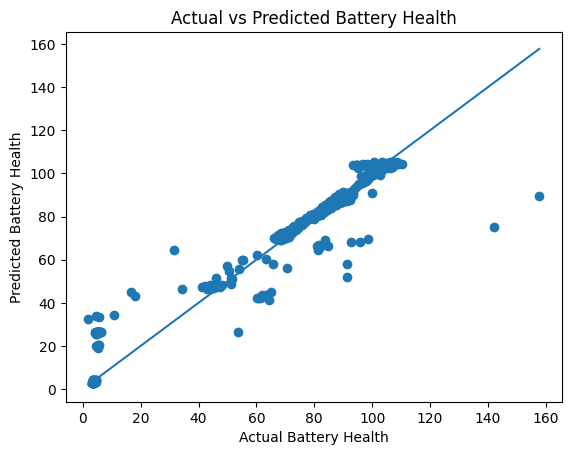

In [5]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Battery Health")
plt.ylabel("Predicted Battery Health")
plt.title("Actual vs Predicted Battery Health")
plt.show()

**Residual Analysis**

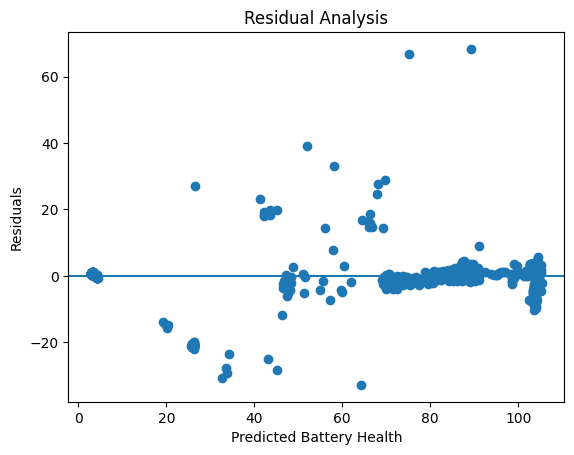

In [6]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Battery Health")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

**Coefficient Analysis**

In [7]:
feature_names = [
    "voltage_mean",
    "voltage_max",
    "current_mean",
    "temp_max",
    "voltage_range",
    "temp_current_stress",
    "current_voltage_ratio"
]

**Error Distribution Plot**

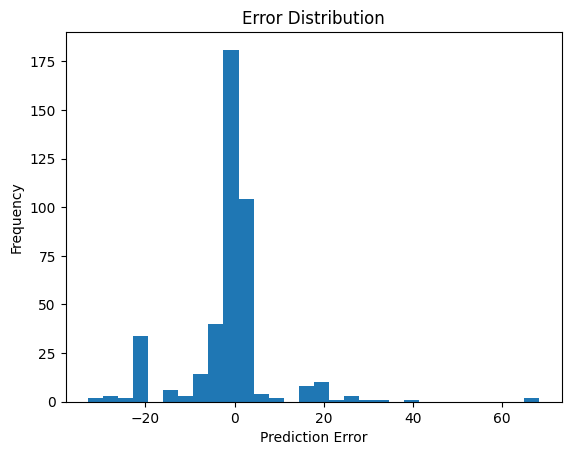

In [8]:
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()